In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Portfolio/Data Analyst/Netflix Movies and Shows/netflix_titles.csv")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df_clean = df.copy()

# Data Cleaning

## Mengubah type menjadi datetime

In [5]:
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"].str.strip())

In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


## Mengisi nilai null

In [7]:
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
df_clean["director"] = df_clean["director"].fillna('Unknown')
df_clean["cast"] = df_clean["cast"].fillna('Unknown')
df_clean["country"] = df_clean["country"].fillna("Unknown")

## Menghapus baris null

In [9]:
df_clean.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

In [10]:
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


## Explode kolom country

In [11]:
df_clean.shape

(8790, 12)

In [12]:
df_country = df_clean.copy()
df_country['country'] = df_clean["country"].str.split(', ')
df_country = df_country.explode('country')

In [13]:
df_country.shape

(10828, 12)

In [14]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   cast          8790 non-null   object        
 5   country       8790 non-null   object        
 6   date_added    8790 non-null   datetime64[ns]
 7   release_year  8790 non-null   int64         
 8   rating        8790 non-null   object        
 9   duration      8790 non-null   object        
 10  listed_in     8790 non-null   object        
 11  description   8790 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 892.7+ KB


In [15]:
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# Exploratory Data Analysis

## Komposisi Tipe Konten

In [16]:
print(df_clean['type'].value_counts())

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


In [17]:
print(df_clean['type'].value_counts(normalize=True) * True)

type
Movie      0.696928
TV Show    0.303072
Name: proportion, dtype: float64


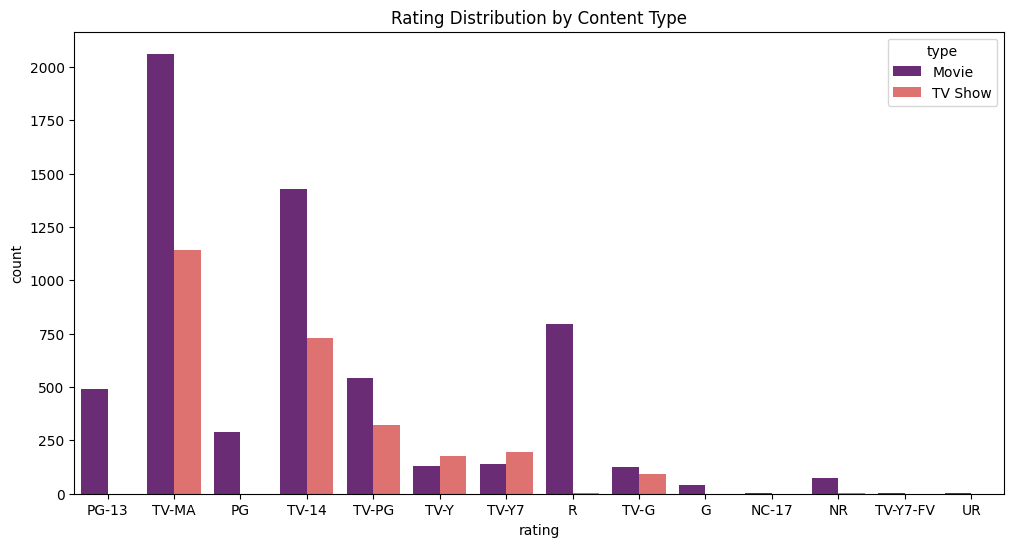

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, x='rating', hue='type', palette='magma')
plt.title('Rating Distribution by Content Type')
# plt.savefig('rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Berdasarkan distribusi rating konten, ditemukan bahwa segmen TV-MA (Mature Audience) mendominasi platform, terutama pada kategori Movie dibandingkan TV Show. Hal ini mengindikasikan bahwa Netflix memiliki fokus strategis yang kuat dalam menyajikan konten dewasa. Posisi berikutnya ditempati oleh TV-14 yang menyasar penonton remaja, disusul oleh rating R (Restricted) yang mempertegas kedalaman pustaka konten untuk audiens matang.

## Analisis Tren Waktu

In [20]:
df_clean["year_added"] = df_clean["date_added"].dt.year
trend_data = df_clean.groupby(['year_added', 'type']).size().reset_index(name='count')
trend_data = trend_data[trend_data['year_added'] >= 2008]
print(trend_data.tail(10))

    year_added     type  count
14        2017    Movie    836
15        2017  TV Show    349
16        2018    Movie   1237
17        2018  TV Show    411
18        2019    Movie   1424
19        2019  TV Show    592
20        2020    Movie   1284
21        2020  TV Show    595
22        2021    Movie    993
23        2021  TV Show    505


dilakukan filter mulai tahun 2008 untuk menyesuaikan dengan lini masa Netflix saat bertransformasi menjadi layanan streaming. Hal ini dilakukan agar analisis fokus pada era pertumbuhan digital mereka dan menghindari distorsi data dari masa transisi bisnis DVD fisik ke video-on-demand.

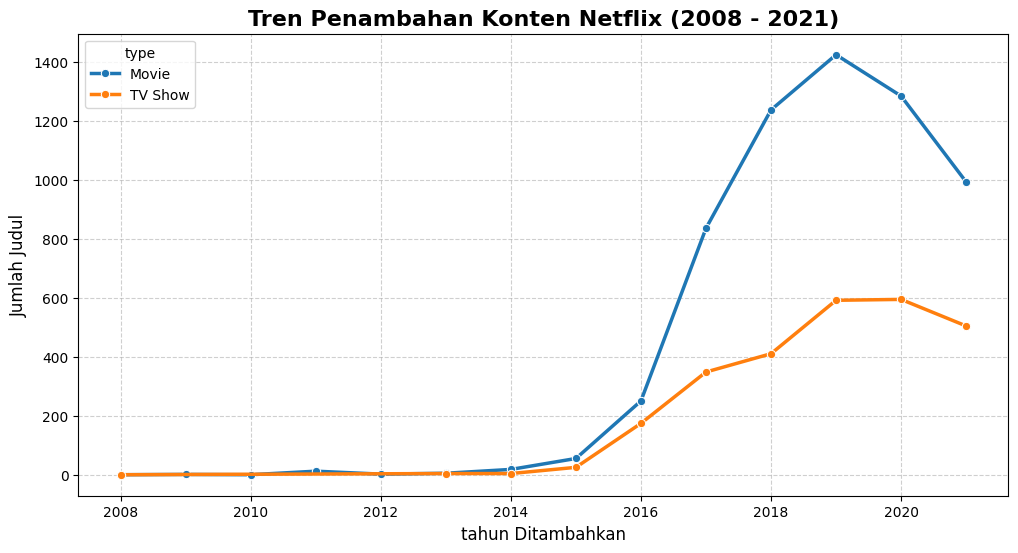

In [21]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_data, x='year_added', y='count', hue='type', marker='o', linewidth=2.5)

plt.title('Tren Penambahan Konten Netflix (2008 - 2021)', fontsize=16, fontweight='bold')
plt.xlabel('tahun Ditambahkan', fontsize=12)
plt.ylabel('Jumlah Judul', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
# plt.savefig('content_growth.png', dpi=300, bbox_inches='tight')
plt.show()

Analisis tren menunjukkan fase ekspansi masif pada kategori Movie antara tahun 2016 hingga 2017, dengan penambahan mencapai puncaknya di angka ~700 judul. Namun, terjadi pergeseran tren pasca-2018 di mana volume film mulai mengalami dekselerasi. Sebaliknya, kategori TV Show menunjukkan pertumbuhan yang jauh lebih stabil dan konsisten setiap tahunnya. Hal ini mengindikasikan adanya perubahan fokus strategi Netflix dari kuantitas konten film menuju penguatan retensi pelanggan melalui serial (TV Shows) yang memiliki durasi tonton (watch time) lebih lama.

## Analisis Genre

In [22]:
df_genre = df_clean.copy()
df_genre['genre'] = df_genre['listed_in'].str.split(', ')
df_genre = df_genre.explode('genre')

# Top 10 Genre
top_10_genres = df_genre['genre'].value_counts().head(10)
print("10 Genre Terbesar di Netflix: ")
print(top_10_genres)

10 Genre Terbesar di Netflix: 
genre
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


/tmp/ipykernel_14673/1975676302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette="viridis")


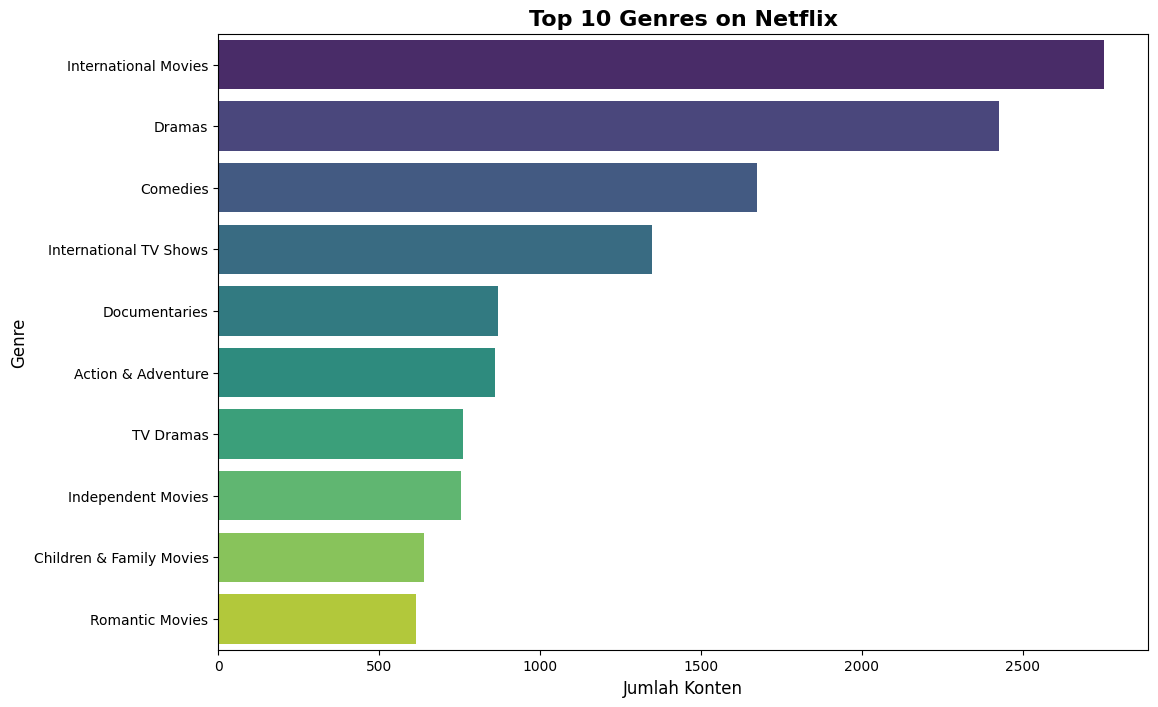

In [23]:
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette="viridis")

plt.title("Top 10 Genres on Netflix", fontsize = 16, fontweight='bold')
plt.xlabel("Jumlah Konten", fontsize = 12)
plt.ylabel("Genre", fontsize = 12)
# plt.savefig('top_genres.png', dpi=300, bbox_inches='tight')
plt.show()

Berdasarkan hasil analisis, International Movies menempati posisi puncak sebagai genre paling dominan dengan lebih dari 2.500 judul, disusul oleh Dramas dan Comedies. Dominasi genre International Movies ini berkorelasi erat dengan temuan sebelumnya yang menempatkan India sebagai salah satu produser konten terbesar di platform Netflix. Hal ini menunjukkan strategi agresif Netflix dalam melakukan ekspansi global; dengan menyajikan konten lokal yang relevan bagi pasar internasional, Netflix tidak hanya meningkatkan basis pelanggan di berbagai negara tetapi juga mendiversifikasi portofolionya dengan konten yang memiliki efisiensi biaya produksi lebih baik dibandingkan produksi domestik US.

In [24]:
intl_dramas = df_clean[(df_clean['listed_in'].str.contains('International Movies')) &
                       (df_clean['listed_in'].str.contains('Dramas'))].shape[0]

print(f"Jumlah International Movies yang bergenre Dramas: {intl_dramas}")

Jumlah International Movies yang bergenre Dramas: 1483


## Analisis "Maturity Level" Berdasarkan Negara

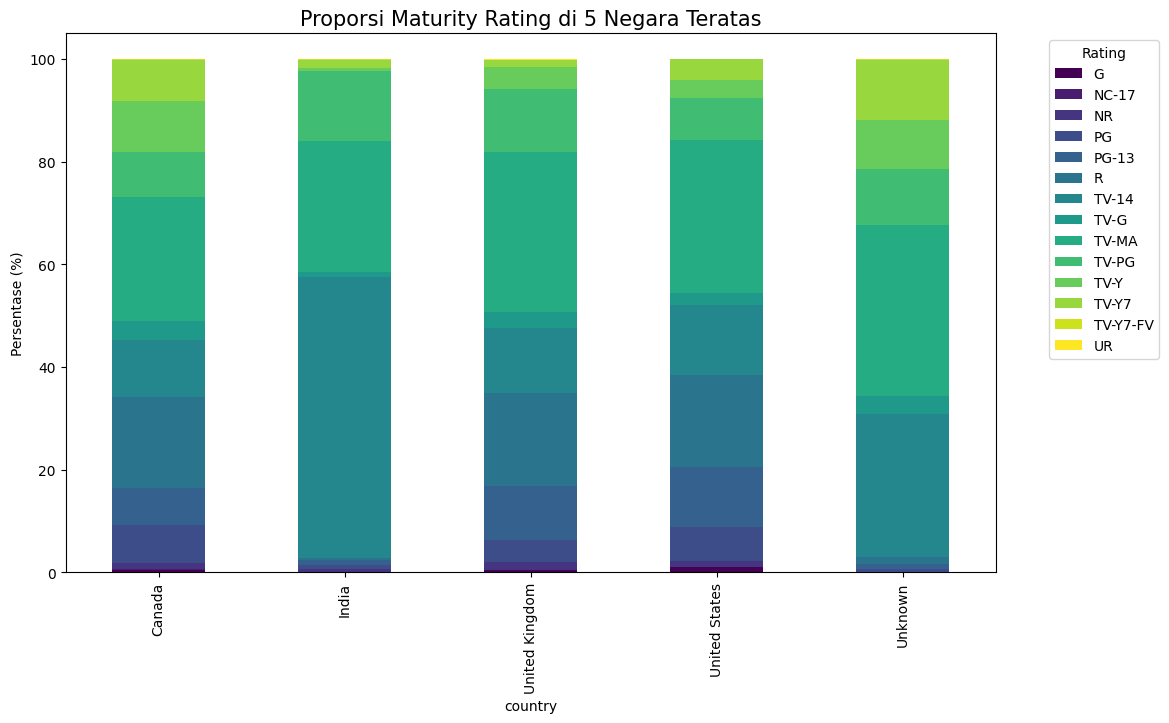

In [25]:
# Ambil top 5 negara
top_5_countries = df_country['country'].value_counts().head(5).index
df_top_5 = df_country[df_country['country'].isin(top_5_countries)]

# Membuat Cross-tabulation
rating_country = pd.crosstab(df_top_5['country'], df_top_5['rating'], normalize='index') * 100

# Visualisasi dengan Stacked Bar Chart
rating_country.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Proporsi Maturity Rating di 5 Negara Teratas', fontsize=15)
plt.ylabel('Persentase (%)')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('rating_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Meskipun Netflix secara global didominasi oleh konten bertipe TV-MA (Mature Audiences), pasar India menunjukkan karakteristik yang berbeda secara signifikan dengan tingginya proporsi konten rating TV-G (General Audience). Hal ini merefleksikan strategi lokalisasi Netflix di Asia Selatan yang berfokus pada konten ramah keluarga untuk menjangkau basis pelanggan yang lebih luas di wilayah dengan budaya konsumsi media berbasis keluarga yang kuat.

## Analisis Durasi Movie vs Tahun *Rilis*

In [26]:
df_clean['duration_num'] = df_clean['duration'].str.split(' ').str[0].fillna(0).astype(int)
movies_df = df_clean[df_clean['type'] == 'Movie'].copy()
print(movies_df[['title', 'duration', 'duration_num']].head())

                               title duration  duration_num
0               Dick Johnson Is Dead   90 min            90
6   My Little Pony: A New Generation   91 min            91
7                            Sankofa  125 min           125
9                       The Starling  104 min           104
12                      Je Suis Karl  127 min           127


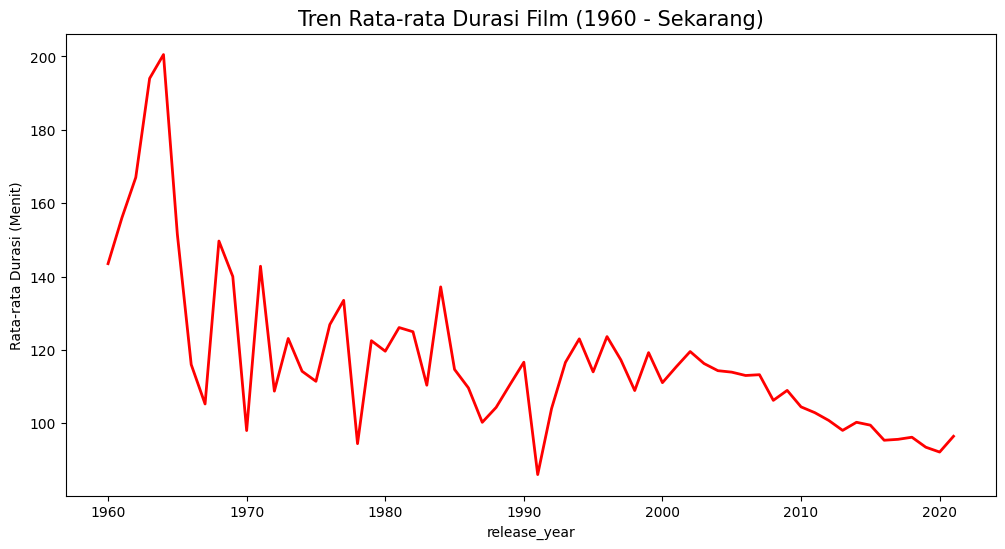

In [27]:
# Ambil rata-rata durasi per tahun rilis
duration_trend = movies_df.groupby('release_year')['duration_num'].mean().reset_index()

# Filter dari tahun 1960
duration_trend = duration_trend[duration_trend['release_year'] >= 1960]

plt.figure(figsize=(12, 6))
sns.lineplot(data=duration_trend, x='release_year', y='duration_num', color='red', linewidth=2)
plt.title('Tren Rata-rata Durasi Film (1960 - Sekarang)', fontsize=15)
plt.ylabel('Rata-rata Durasi (Menit)')
# plt.savefig('movie_duration_trend.png', dpi=300, bbox_inches='tight')
plt.show()

Analisis tren durasi film mengungkapkan adanya pergeseran pola produksi dari tahun 1960 hingga sekarang. Sejak memasuki milenium baru (pasca-2000), durasi film di platform Netflix terkonsolidasi secara konsisten di bawah ambang 120 menit. Fenomena ini mengindikasikan standarisasi durasi yang lebih efisien untuk platform streaming guna menjaga tingkat retensi penonton (watch time) tanpa risiko kelelahan durasi (duration fatigue).